In [ ]:
import pandas as pd


#data from the weather stations
headers = ['yyyy', 'mm', 'tmax', 'tmin', 'af', 'rain', 'sun']
dtype = {'yyyy': int, 'mm':int, 'tmax degC':float, 'tmin degC':float, 'af days':int, 'rain mm':float, 'sun hours':float}
weather_station_df = pd.read_csv(r"suttonboningtondata.txt", sep=r'\s+', header=None, on_bad_lines='skip')
weather_station_df.columns = headers

#print(df.head())


headers = ['Unix', 'Aggregate', 'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']

df1 = pd.read_csv(r"House1.csv")
df2 = pd.read_csv(r"House2.csv")
df3 = pd.read_csv(r"House3.csv")
df4 = pd.read_csv(r"House4.csv")
df5 = pd.read_csv(r"House5.csv")
df6 = pd.read_csv(r"House6.csv")
df7 = pd.read_csv(r"House7.csv")
df8 = pd.read_csv(r"House8.csv")
df9 = pd.read_csv(r"House9.csv")
df10 = pd.read_csv(r"House10.csv")
df11 = pd.read_csv(r"House11.csv")
df12 = pd.read_csv(r"House12.csv")
df13 = pd.read_csv(r"House13.csv")
#No data for house 14
df15 = pd.read_csv(r"House15.csv")
df16 = pd.read_csv(r"House16.csv")
df17 = pd.read_csv(r"House17.csv")
df18 = pd.read_csv(r"House18.csv")
df19 = pd.read_csv(r"House19.csv")
df20 = pd.read_csv(r"House20.csv")
df21 = pd.read_csv(r"House21.csv")

dataframes = [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10,
              df11, df12, df13, df15, df16, df17, df18, df19, df20, df21]

#add a header to the REFIT data
for data in dataframes:
    data.columns = headers

#Put which house the data is from for each house
for i, data in enumerate(dataframes):
    if i < 13:
        data['House'] = i + 1
    else: 
        data['House'] = i + 2


#Convert the Unix time to mm/dd/yyyy
#Group the data by the day and average out the values
condensed_data = []

for data in dataframes:
    data['datetime'] = pd.to_datetime(data['Unix'], unit='s')
    data['date'] = data['datetime'].dt.date
    condensed = data.groupby('date').agg({'Aggregate':'mean', 'Appliance1':'mean', 'Appliance2':'mean', 'Appliance3':'mean', 'Appliance4':'mean', 'Appliance5':'mean', 'Appliance6':'mean', 'Appliance7':'mean', 'Appliance8':'mean', 'Appliance9':'mean', 'House':'mean'}).reset_index()
    condensed_data.append(condensed)

total_REFIT_data = pd.concat(condensed_data, ignore_index=True)

#Data from visualcrossing
visualcrossing_df = pd.read_csv(r"Loughborough 2014-01-01 to 2015-12-31.csv")
visualcrossing_df.drop(columns=['name', 'description', 'icon', 'stations'], inplace=True)


In [ ]:
from tabulate import tabulate

temp_REFIT = total_REFIT_data.copy()
temp_visual = visualcrossing_df.copy()

#sorting data by date
start_date = '2014-01-01'
end_date = '2015-12-31'
start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)

temp_REFIT['date'] = pd.to_datetime(temp_REFIT['date'])
filtered_REFIT = temp_REFIT[(temp_REFIT['date'] >= start_date) & (temp_REFIT['date'] <= end_date)]
#extracting year and month
filtered_REFIT['year'] = filtered_REFIT['date'].dt.year
filtered_REFIT['month'] = filtered_REFIT['date'].dt.month

#grouping by the month
grouped = filtered_REFIT.groupby(['year', 'month'])

monthly_REFIT = {}

for (year, month), data in grouped:
    month_str = f"{year}-{month:02}"
    monthly_REFIT[month_str] = data.copy()


#doing the same thing for the visualcrossing dataframe
temp_visual['date'] = pd.to_datetime(temp_visual['datetime'])

filtered_visual = temp_visual[(temp_visual['date'] >= start_date) & (temp_visual['date'] <= end_date)]
filtered_visual['year'] = filtered_visual['date'].dt.year
filtered_visual['month'] = filtered_visual['date'].dt.month

grouped = filtered_visual.groupby(['year', 'month'])

monthy_visual = {}

for (year, month), data in grouped:
    month_str = f"{year}-{month:02}"
    monthy_visual[month_str] = data.copy()

#combine the dataframes into one
monthly_electricty_and_weather = {}
for month_str, refit_df in monthly_REFIT.items():
    if month_str in monthy_visual:
        visual_df = monthy_visual[month_str]
        combined = pd.merge(refit_df, visual_df, on='date', how='inner')
        monthly_electricty_and_weather[month_str] = combined
    else:
        print(f"\n\nMissing weather data for {month_str}\n\n")


print(monthly_electricty_and_weather['2014-01'].columns)
print(tabulate(monthly_electricty_and_weather, headers='keys', tablefmt='fancy_grid', showindex=False))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for date in monthly_electricty_and_weather:
    x = monthly_electricty_and_weather[date]['temp']
    y = monthly_electricty_and_weather[date]['Aggregate']
    hue = monthly_electricty_and_weather[date]['House']
    sns.scatterplot(x = x,
                    y = y,
                    hue = hue,
                    palette = 'tab20',
                    legend = False,
                    data = monthly_electricty_and_weather[date])
    plt.xlim(32,70)
    plt.ylim(0, 1500)
    plt.title(f'Average Power Usage vs Temperatue for {date}')
    plt.show()

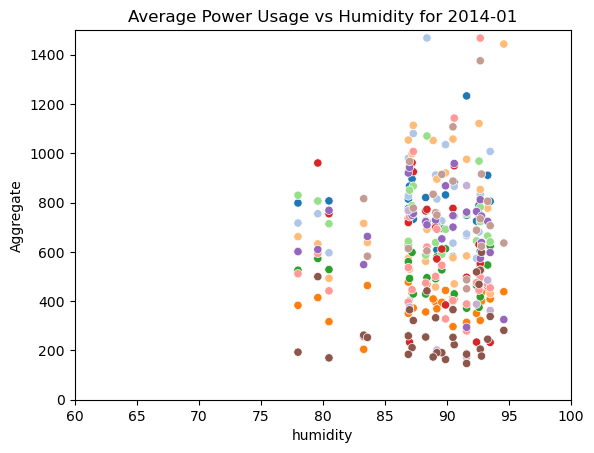

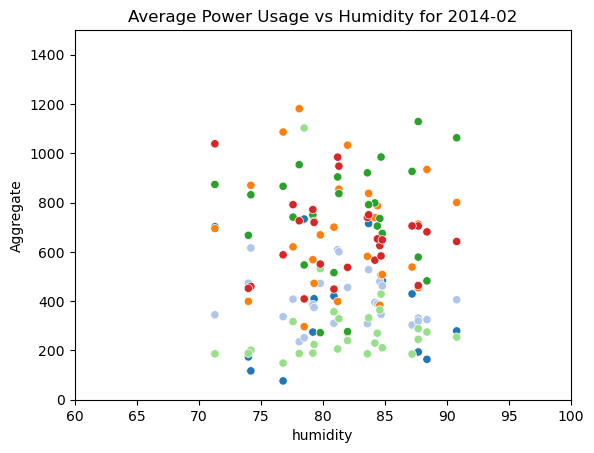

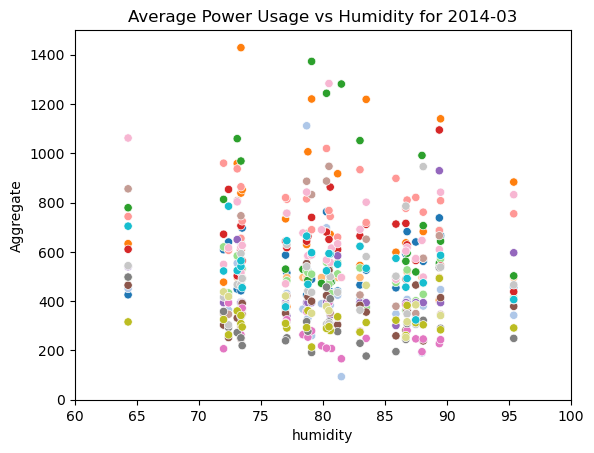

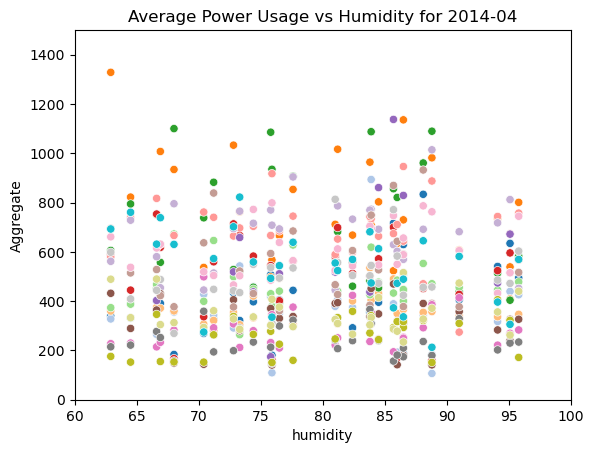

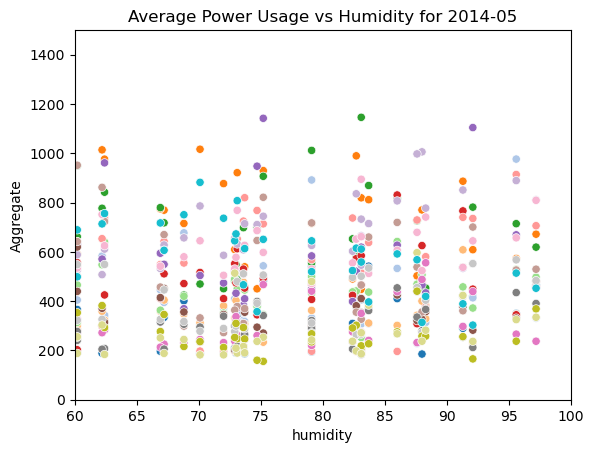

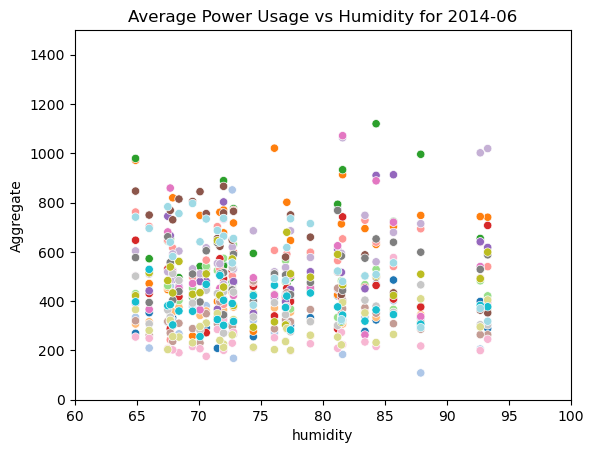

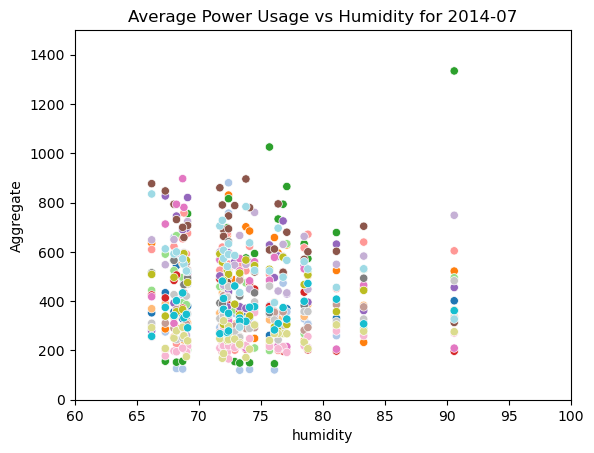

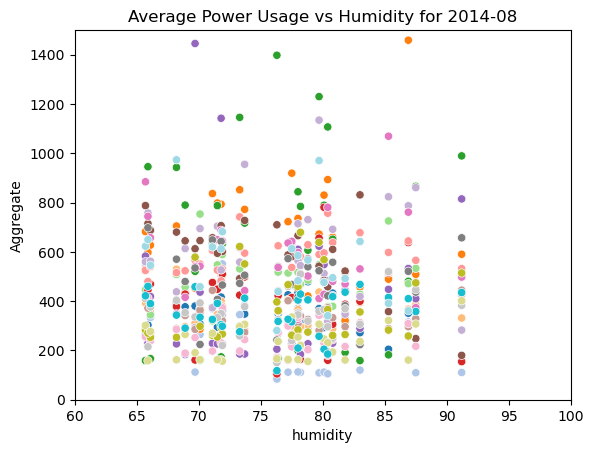

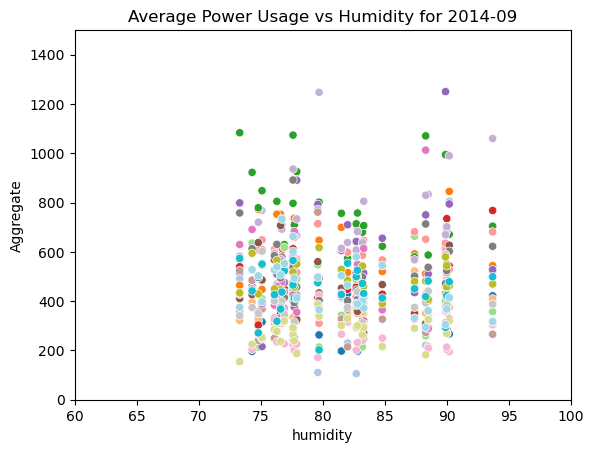

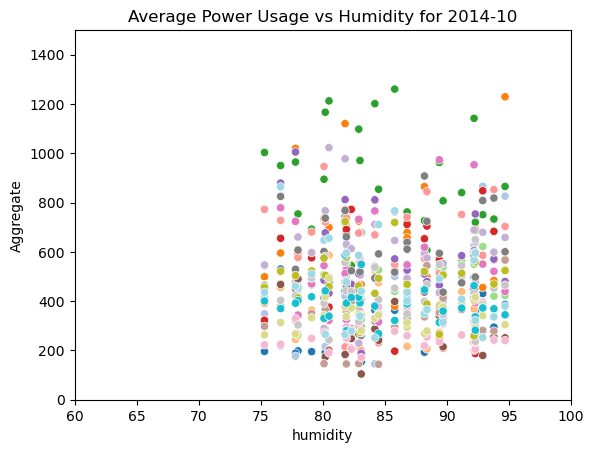

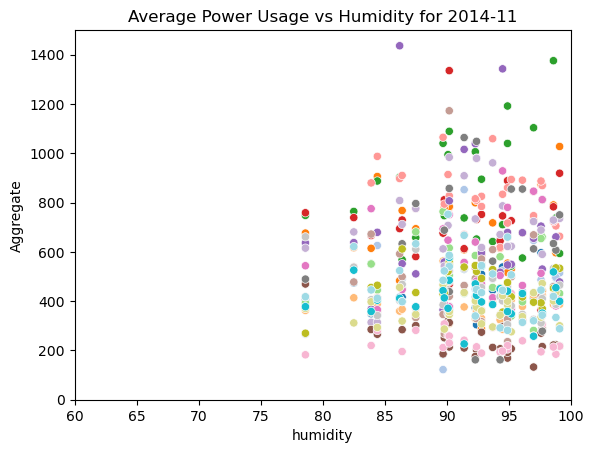

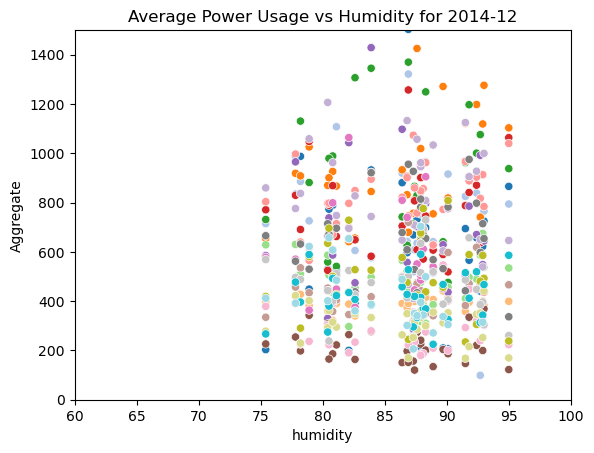

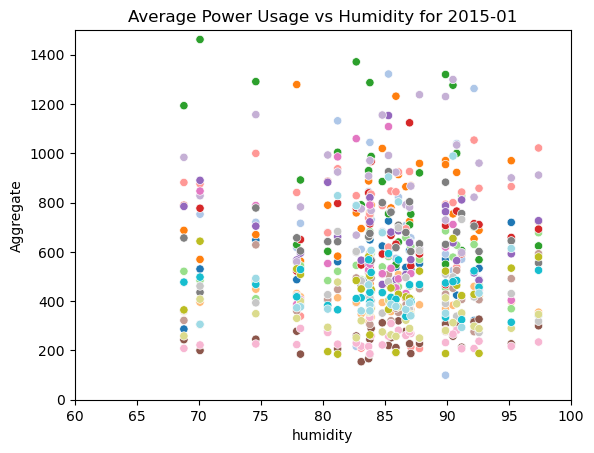

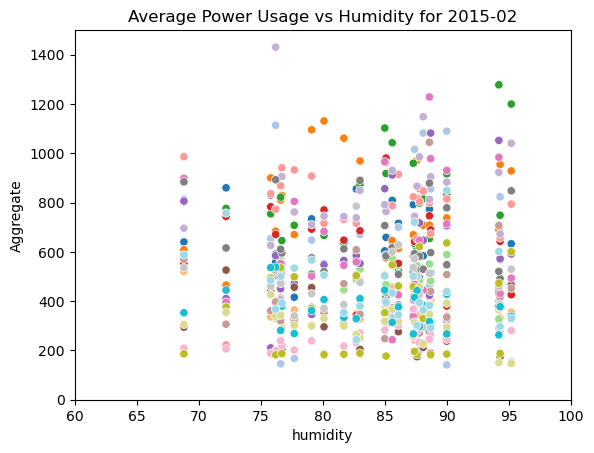

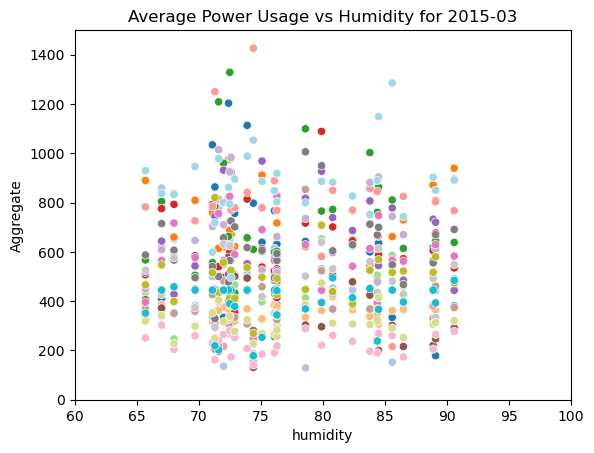

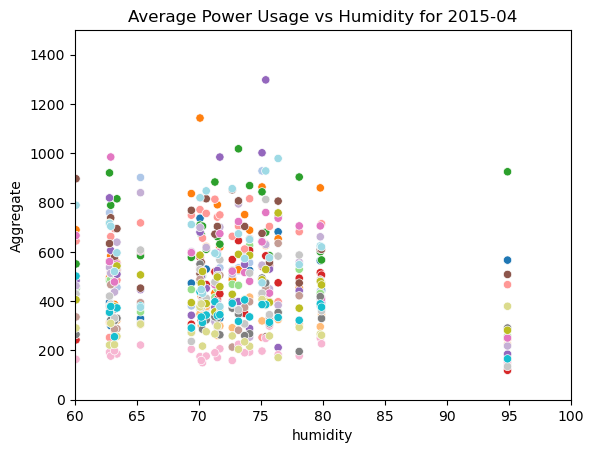

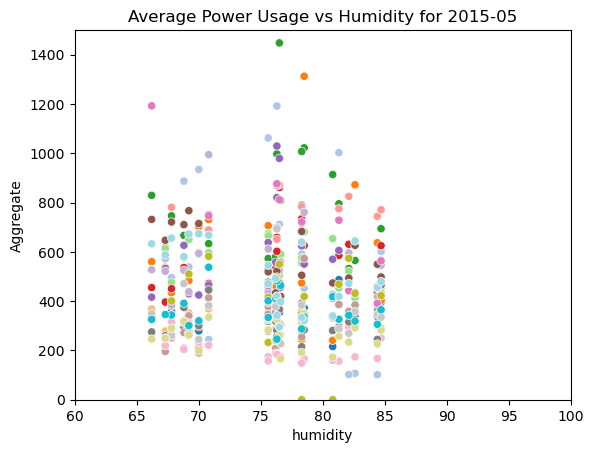

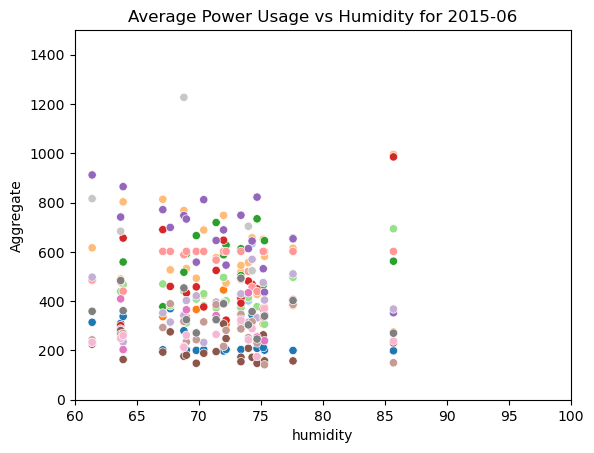

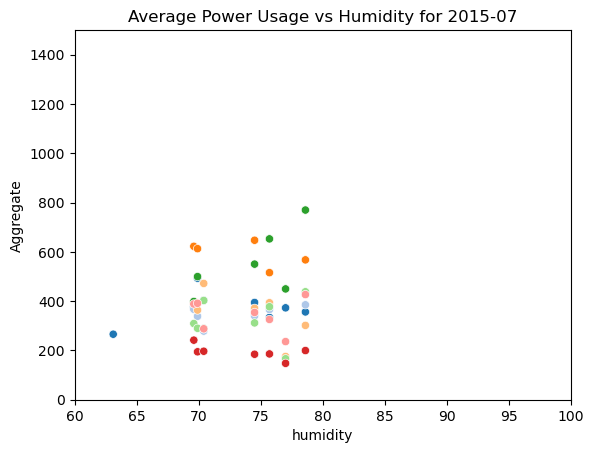

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

for date in monthly_electricty_and_weather:
    x = monthly_electricty_and_weather[date]['humidity']
    y = monthly_electricty_and_weather[date]['Aggregate']
    hue = monthly_electricty_and_weather[date]['House']
    sns.scatterplot(x = x,
                    y = y,
                    hue = hue,
                    palette = 'tab20',
                    legend = False,
                    data = monthly_electricty_and_weather[date])
    plt.ylim(0, 1500)
    plt.xlim(60, 100)
    plt.title(f'Average Power Usage vs Humidity for {date}')
    plt.show()

In [49]:
#Looking at the data based off the year
#going to look at 2014 year because it has a full year of data
temp_REFIT = total_REFIT_data.copy()
temp_visual = visualcrossing_df.copy()

#sorting data by date
start_date = '2014-01-01'
end_date = '2014-12-31'
start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)

#converting to date time and limiting to just 2014
temp_REFIT['date'] = pd.to_datetime(temp_REFIT['date'])
filtered_REFIT = temp_REFIT[(temp_REFIT['date'] >= start_date) & (temp_REFIT['date'] <= end_date)]
filtered_REFIT = filtered_REFIT.sort_values(by='date')

#doing the same thing for the visualcrossing dataframe
temp_visual['date'] = pd.to_datetime(temp_visual['datetime'])
filtered_visual = temp_visual[(temp_visual['date'] >= start_date) & (temp_visual['date'] <= end_date)]
filtered_visual = filtered_visual.sort_values(by='date')

#combine the dataframes into one
yearly_electricity_and_weather = pd.merge(filtered_REFIT, filtered_visual, on ='date', how='inner')

print(yearly_electricity_and_weather.columns)

Index(['date', 'Aggregate', 'Appliance1', 'Appliance2', 'Appliance3',
       'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8',
       'Appliance9', 'House', 'datetime', 'tempmax', 'tempmin', 'temp',
       'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity',
       'precip', 'precipprob', 'precipcover', 'preciptype', 'snow',
       'snowdepth', 'windgust', 'windspeed', 'winddir', 'sealevelpressure',
       'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex',
       'severerisk', 'sunrise', 'sunset', 'moonphase', 'conditions'],
      dtype='object')


In [ ]:
#remove the outliers to try and clean up the data
import numpy as np
from scipy import stats

z_scores = np.abs(stats.zscore(yearly_electricity_and_weather['Aggregate']))
filter_yearly_electricity_and_weather = yearly_electricity_and_weather[z_scores < 3]

Text(0.5, 1.0, 'Average Power Usage for 2014')

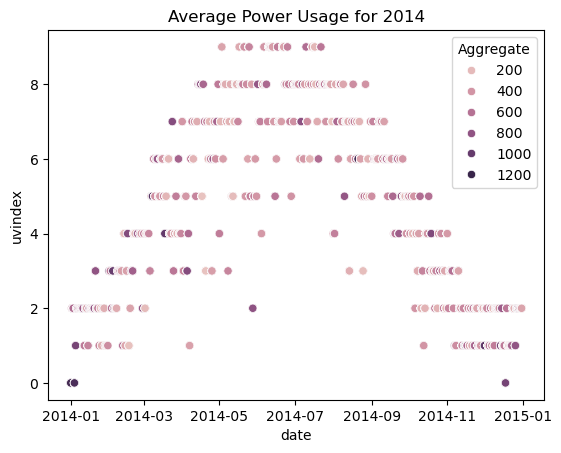

In [181]:
y = filter_yearly_electricity_and_weather['uvindex']
x = filter_yearly_electricity_and_weather['date']
hue = filter_yearly_electricity_and_weather['Aggregate']
sns.scatterplot(x = x,
                    y = y,
                    hue = hue,
                    data = filter_yearly_electricity_and_weather)
plt.title(f'Average Power Usage for 2014')

Text(0.5, 1.0, 'Average Power Usage for 2014')

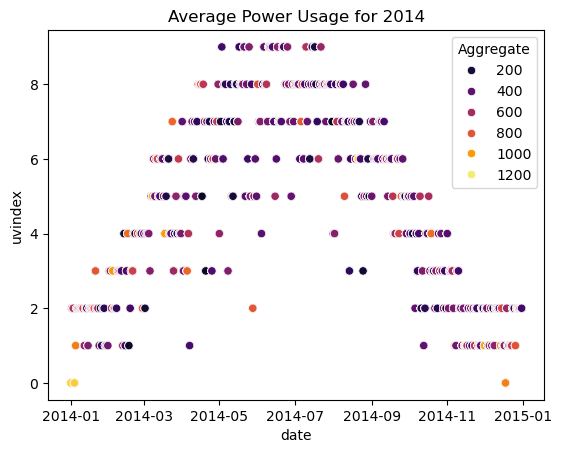

In [182]:
y = filter_yearly_electricity_and_weather['uvindex']
x = filter_yearly_electricity_and_weather['date']
hue = filter_yearly_electricity_and_weather['Aggregate']
sns.scatterplot(x = x,
                    y = y,
                    hue = hue,
                    palette = 'inferno',
                    data = filter_yearly_electricity_and_weather)
plt.title(f'Average Power Usage for 2014')

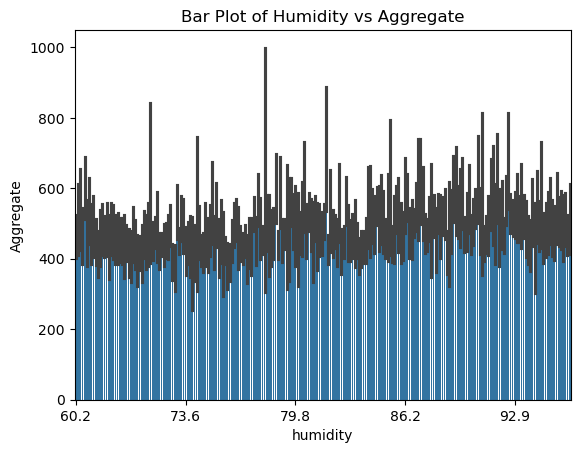

In [189]:
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression

x = filter_yearly_electricity_and_weather['humidity']
y = filter_yearly_electricity_and_weather['Aggregate']
sns.barplot(x = x,
            y = y,
            data = filter_yearly_electricity_and_weather)
plt.title('Bar Plot of Humidity vs Aggregate')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins = 5))
plt.show()

Text(0.5, 1.0, 'Linear Regression of Temperature and Power Usage')

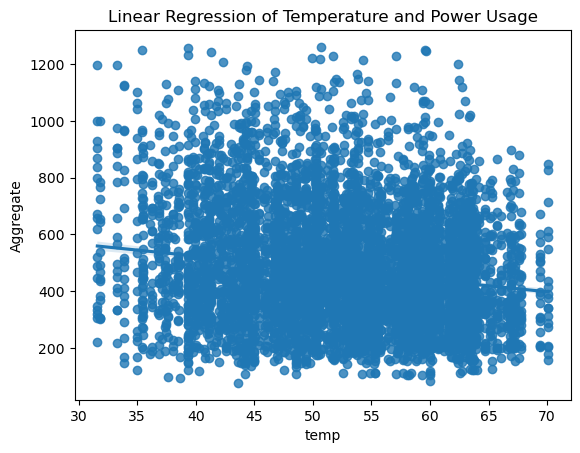

In [ ]:
'''
Linear Regression doesn't seem to really match well with the data. Lots of outliers. So I chose not to use this
'''
x = filter_yearly_electricity_and_weather['temp']
y = filter_yearly_electricity_and_weather['Aggregate']
sns.regplot(x = x,
            y = y,
            robust = True,
            data = filter_yearly_electricity_and_weather)
plt.title('Linear Regression of Temperature and Power Usage')